<a href="https://colab.research.google.com/github/gilangf03/Tugas-Pertemuan4/blob/main/segmentasi_warna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import active_contour
from skimage.color import rgb2gray
from skimage import img_as_float


(np.float64(-0.5), np.float64(1499.5), np.float64(997.5), np.float64(-0.5))

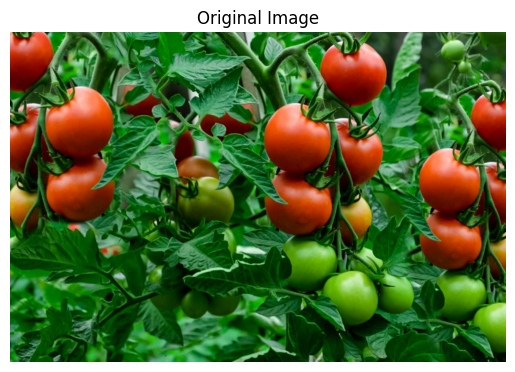

In [8]:
import cv2
import matplotlib.pyplot as plt

# Load langsung dari file
img = cv2.imread('tomat.jpg')

# Cek apakah gambar ada
if img is None:
    raise ValueError("File 'tomat.jpg' tidak ditemukan di direktori Colab.")

# Convert warna
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Tampilkan
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')

(np.float64(-0.5), np.float64(1499.5), np.float64(997.5), np.float64(-0.5))

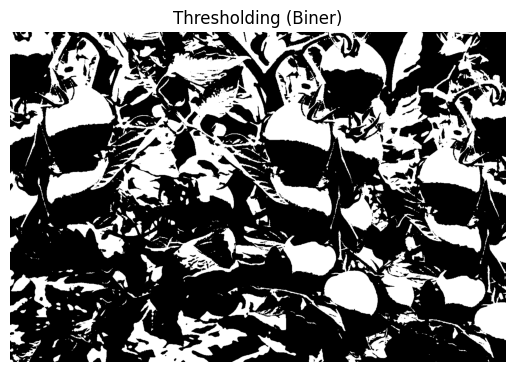

In [9]:
# Thresholding OTSU
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(thresh, cmap='gray')
plt.title("Thresholding (Biner)")
plt.axis('off')

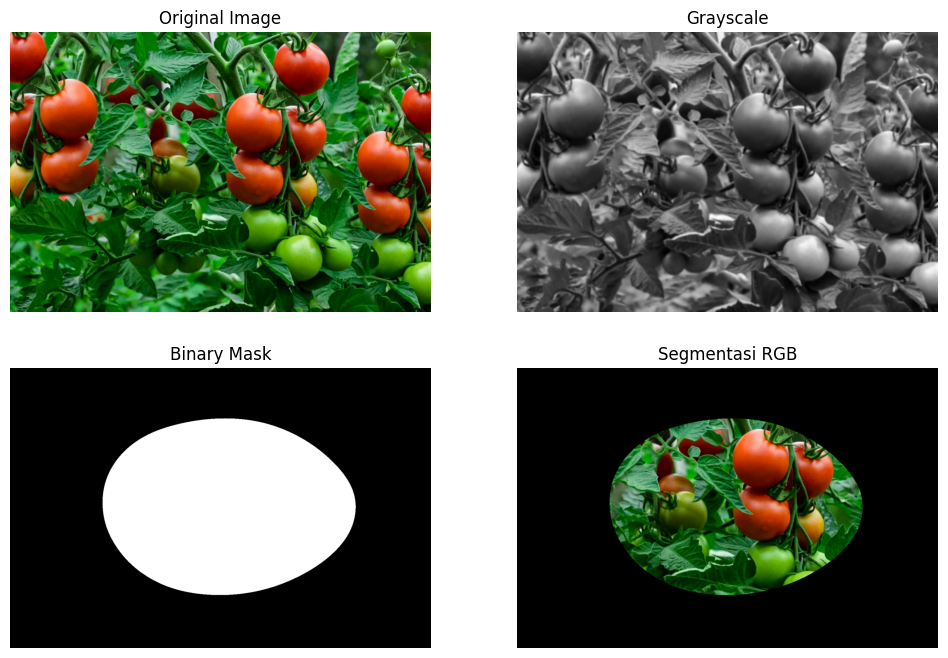

In [11]:
# Install library
!pip install scikit-image opencv-python matplotlib

# Import library
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import color
from skimage.segmentation import active_contour
from skimage.draw import polygon
from skimage.filters import gaussian

# =========================
# LOAD GAMBAR (tanpa upload)
# =========================
image = cv2.imread('tomat.jpg')   # pastikan file ada di folder Colab

# Cek error
if image is None:
    raise ValueError("File 'tomat.jpg' tidak ditemukan! Cek path atau nama file.")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# =========================
# PREPROCESSING
# =========================
gray = color.rgb2gray(image)

# Blur supaya kontur lebih halus
gray = gaussian(gray, 2)

# =========================
# INISIALISASI SNAKE
# =========================
h, w = gray.shape

s = np.linspace(0, 2*np.pi, 400)
r = h/2 + h/3*np.sin(s)
c = w/2 + w/3*np.cos(s)
init = np.array([r, c]).T

# =========================
# ACTIVE CONTOUR
# =========================
snake = active_contour(gray, init, alpha=0.01, beta=10, gamma=0.001)

# =========================
# MASK BINER
# =========================
mask = np.zeros(gray.shape, dtype=np.uint8)

rr, cc = polygon(snake[:,0], snake[:,1], mask.shape)
mask[rr, cc] = 255

# =========================
# SEGMENTASI RGB
# =========================
segmented = cv2.bitwise_and(image, image, mask=mask)

# =========================
# TAMPILKAN HASIL (4 OUTPUT)
# =========================
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(segmented)
plt.title("Segmentasi RGB")
plt.axis("off")

plt.show()

(np.float64(-0.5), np.float64(1499.5), np.float64(997.5), np.float64(-0.5))

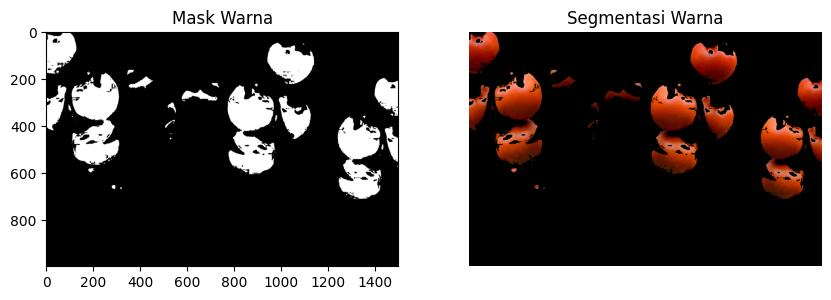

In [12]:
# Convert ke HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Range warna (contoh: merah)
lower = np.array([0, 120, 70])
upper = np.array([10, 255, 255])

mask = cv2.inRange(hsv, lower, upper)
result = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(mask, cmap='gray')
plt.title("Mask Warna")

plt.subplot(1,2,2)
plt.imshow(result)
plt.title("Segmentasi Warna")
plt.axis('off')

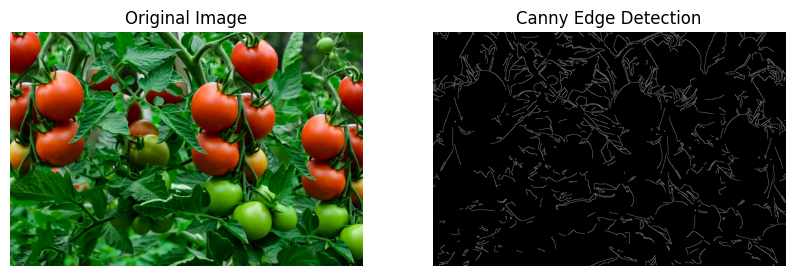

In [15]:
import cv2
import matplotlib.pyplot as plt

# =========================
# LOAD GAMBAR
# =========================
img = cv2.imread('tomat.jpg')

if img is None:
    raise ValueError("File 'tomat.jpg' tidak ditemukan!")

# Convert ke RGB & Grayscale
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# =========================
# PREPROCESSING
# =========================
# Blur untuk mengurangi noise
blur = cv2.GaussianBlur(gray, (5,5), 0)

# =========================
# CANNY EDGE DETECTION
# =========================
edges = cv2.Canny(blur, 100, 200)

# =========================
# TAMPILKAN HASIL
# =========================
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')

plt.show()